## Train File

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('../src')

import util as ut

In [2]:
df_train = pd.read_csv("../data/processed/01.2/train_data.csv")
df_test = pd.read_csv("../data/processed/01.2/test_data.csv")

In [3]:
df_train["Start_Time"] = pd.to_datetime(df_train["Start_Time"], errors="coerce")
df_test["Start_Time"] = pd.to_datetime(df_test["Start_Time"], errors="coerce")

In [4]:
missing_data = df_train.isnull().sum()[df_train.isnull().sum() > 0].sort_values(ascending=False)

print("--- Number of Null ---")
print(missing_data)

--- Number of Null ---
Precipitation(in)    1645148
Wind_Chill(F)        1482771
Wind_Speed(mph)       344794
Wind_Direction         33784
Visibility(mi)         32958
Weather_Condition      30777
Humidity(%)            29692
Temperature(F)         22357
dtype: int64


In [5]:
missing_percent = (df_train.isnull().sum() / len(df_train)) * 100
missing_df = missing_percent[missing_percent > 0].sort_values(ascending=False)

print("--- Percent of Null ---")
print(missing_df)

--- Percent of Null ---
Precipitation(in)    30.080825
Wind_Chill(F)        27.111831
Wind_Speed(mph)       6.304410
Wind_Direction        0.617726
Visibility(mi)        0.602623
Weather_Condition     0.562744
Humidity(%)           0.542905
Temperature(F)        0.408788
dtype: float64


#### Impute Weather Condition

In [6]:
print(df_train["Weather_Condition"].unique())
print(df_train["Weather_Condition"].nunique())

['Overcast' 'Fair' 'Clear' 'Mostly Cloudy' 'Partly Cloudy' 'Thunder'
 'Thunderstorm' 'Light Rain' 'Cloudy' 'Light Rain with Thunder' 'Fog'
 'Light Snow' 'Scattered Clouds' 'Light Drizzle' 'N/A Precipitation'
 'Haze' nan 'Thunder in the Vicinity' 'Snow' 'Fair / Windy' 'Drizzle'
 'Rain' 'Heavy Rain' 'Light Thunderstorms and Rain' 'Light Rain / Windy'
 'Mostly Cloudy / Windy' 'Cloudy / Windy' 'Heavy Snow / Windy'
 'Heavy Rain / Windy' 'Wintry Mix' 'Patches of Fog' 'Mist' 'Shallow Fog'
 'Heavy Snow' 'T-Storm' 'Smoke' 'Rain / Windy' 'Blowing Snow'
 'Snow / Windy' 'Light Snow / Windy' 'Fog / Windy' 'Partly Cloudy / Windy'
 'Light Freezing Rain' 'Heavy T-Storm' 'Heavy Thunderstorms and Rain'
 'Thunderstorms and Rain' 'Blowing Dust' 'Wintry Mix / Windy'
 'Light Freezing Fog' 'Showers in the Vicinity' 'Haze / Windy'
 'Light Freezing Drizzle' 'Thunder / Windy' 'Blowing Snow / Windy'
 'Light Rain Showers' 'Light Ice Pellets' 'Light Drizzle / Windy'
 'Light Snow with Thunder' 'Light Snow and Sleet

In [7]:
df_train['Weather_Condition'] = df_train['Weather_Condition'].str.lower()
df_test['Weather_Condition'] = df_test['Weather_Condition'].str.lower()

In [8]:
df_train['Start_Date'] = df_train['Start_Time'].dt.date
df_train['Hour'] = df_train['Start_Time'].dt.hour
df_train['Month'] = df_train['Start_Time'].dt.month

df_test['Start_Date'] = df_test['Start_Time'].dt.date
df_test['Hour'] = df_test['Start_Time'].dt.hour
df_test['Month'] = df_test['Start_Time'].dt.month

In [9]:
weather_first_train = df_train.groupby(['City', 'Start_Date', 'Hour', 'Street'])['Weather_Condition'].transform('first')
df_train['Weather_Condition'] = df_train['Weather_Condition'].fillna(weather_first_train)

weather_first_test = df_test.groupby(['City', 'Start_Date', 'Hour', 'Street'])['Weather_Condition'].transform('first')
df_test['Weather_Condition'] = df_test['Weather_Condition'].fillna(weather_first_test)

In [10]:
print("Null in Weather_Condition (Train):", df_train["Weather_Condition"].isnull().sum())
print("Null in Weather_Condition (Test): ", df_test["Weather_Condition"].isnull().sum())

Null in Weather_Condition (Train): 30517
Null in Weather_Condition (Test):  7583


#### Analyze Weather Condition Keywords
วิเคราะห์คำที่ปรากฏบ่อยที่สุดใน Weather_Condition เพื่อหา Keyword ในการจัดกลุ่ม

C:\Users\PC\AppData\Local\Temp\ipykernel_8140\2593790043.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_weather.values, y=top_20_weather.index, palette='viridis')


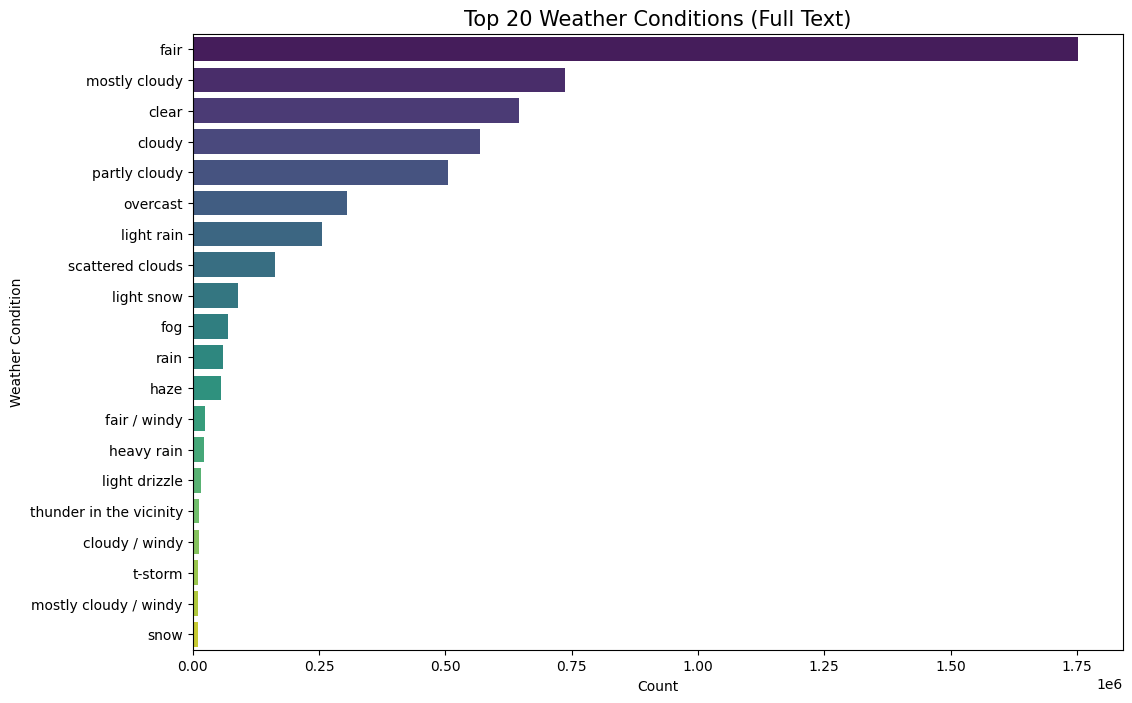


--- Top 50 Most Frequent Words in Weather_Condition ---
cloudy         : 1,841,124
fair           : 1,776,816
mostly         : 748,087
clear          : 645,584
partly         : 512,896
light          : 390,990
rain           : 369,303
overcast       : 305,996
scattered      : 163,730
clouds         : 163,730
snow           : 110,531
fog            : 77,470
windy          : 72,335
haze           : 57,327
heavy          : 38,140
thunder        : 31,011
drizzle        : 21,916
t              : 19,282
storm          : 19,282
in             : 12,710
the            : 12,710
vicinity       : 12,710
smoke          : 9,644
with           : 9,276
and            : 8,589
thunderstorms  : 7,839
wintry         : 7,792
mix            : 7,792
freezing       : 4,447
thunderstorm   : 3,556
patches        : 3,208
of             : 3,208
mist           : 2,715
shallow        : 2,189
n              : 2,073
a              : 2,073
precipitation  : 2,073
blowing        : 1,358
showers        : 1,235
sleet    

In [11]:
from collections import Counter
import re

# 1. Visualizing Top 20 Full Weather Conditions
top_20_weather = df_train['Weather_Condition'].value_counts().head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_20_weather.values, y=top_20_weather.index, palette='viridis')
plt.title('Top 20 Weather Conditions (Full Text)', fontsize=15)
plt.xlabel('Count')
plt.ylabel('Weather Condition')
plt.show()

# 2. Tokenize and count frequent words
all_text = " ".join(df_train['Weather_Condition'].dropna().astype(str).str.lower())
words = re.findall(r'\w+', all_text)
word_counts = Counter(words)

print("\n--- Top 50 Most Frequent Words in Weather_Condition ---")
for word, count in word_counts.most_common(50):
    print(f"{word:15}: {count:,}")

# 3. Check for unmatched conditions
existing_keywords = 'thunder|storm|tornado|gale|snow|sleet|ice|freez|fog|haze|smoke|dust|rain|drizzle|shower|wind|breezy|blustery|gusty|cloud|overcast|clear|fair'
unmatched_conditions = df_train[~df_train['Weather_Condition'].str.contains(existing_keywords, na=False, case=False)]['Weather_Condition'].unique()

print(f"\n--- Samples of Unmatched Conditions ({len(unmatched_conditions)} unique values) ---")
print(unmatched_conditions[:20])

In [12]:
df_train = ut.apply_weather_grouping(df_train)
df_test = ut.apply_weather_grouping(df_test)

# Remove Weather_Condition after grouping
df_train = df_train.drop(columns=['Weather_Condition'])
df_test = df_test.drop(columns=['Weather_Condition'])

C:\Users\PC\AppData\Local\Temp\ipykernel_8140\919224714.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, y='Weather_Group', ax=axes[0], palette='magma', order=df_train['Weather_Group'].value_counts().index)
C:\Users\PC\AppData\Local\Temp\ipykernel_8140\919224714.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_test, y='Weather_Group', ax=axes[1], palette='magma', order=df_test['Weather_Group'].value_counts().index)


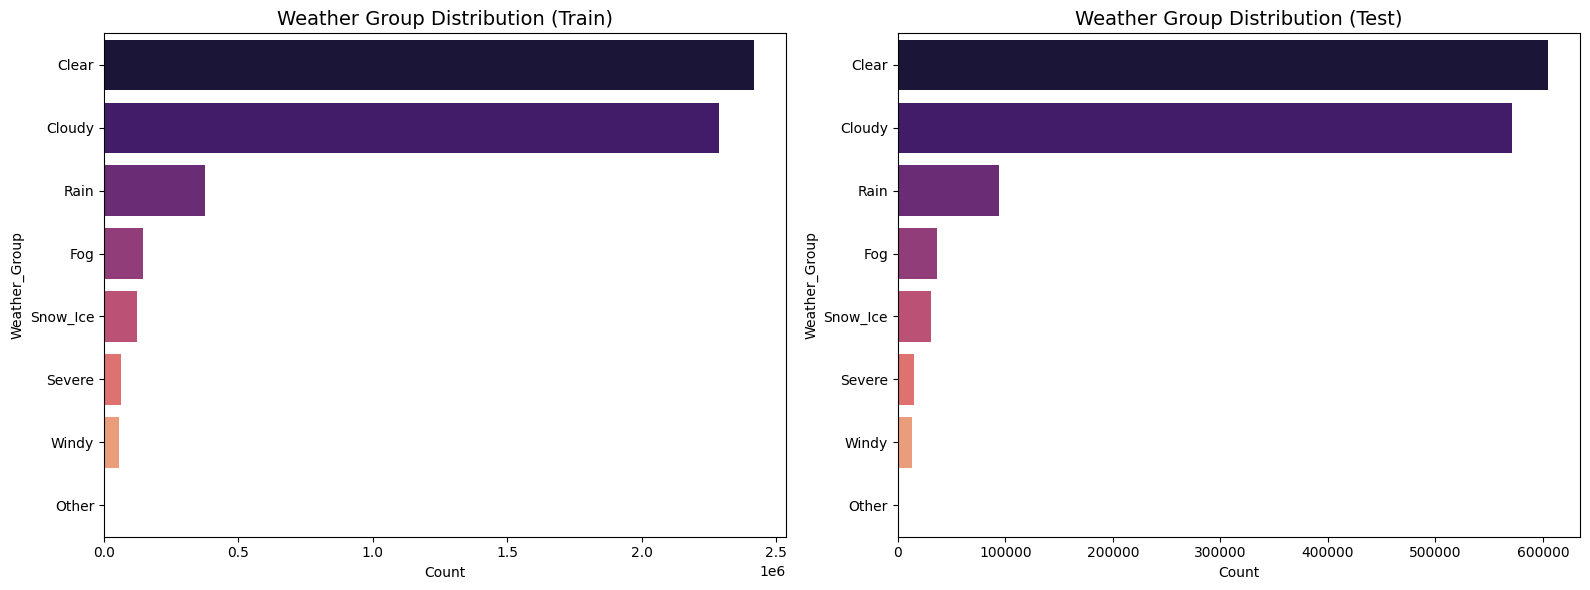

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train Data
sns.countplot(data=df_train, y='Weather_Group', ax=axes[0], palette='magma', order=df_train['Weather_Group'].value_counts().index)
axes[0].set_title('Weather Group Distribution (Train)', fontsize=14)
axes[0].set_xlabel('Count')

# Test Data
sns.countplot(data=df_test, y='Weather_Group', ax=axes[1], palette='magma', order=df_test['Weather_Group'].value_counts().index)
axes[1].set_title('Weather Group Distribution (Test)', fontsize=14)
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

In [14]:
# Hierarchical Imputation
from pandas.api.types import is_numeric_dtype, is_string_dtype, is_object_dtype

hierarchies = [
    ['City', 'Start_Date', 'Hour'],  
    ['City', 'Start_Date'],        
    ['City', 'Month'],           
    ['Weather_Group']            
]

num_weather_cols = [
    'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 
    'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', "Wind_Direction"
]

print("Hierarchical Imputation for df_train...")
for col in num_weather_cols:
    for group_cols in hierarchies:
        if df_train[col].isnull().sum() == 0: break
        if is_numeric_dtype(df_train[col]):
            df_train[col] = df_train[col].fillna(df_train.groupby(group_cols)[col].transform('median'))
        elif is_string_dtype(df_train[col]) or is_object_dtype(df_train[col]):
            df_train[col] = df_train[col].fillna(df_train.groupby(group_cols)[col].transform('first'))

print("Hierarchical Imputation for df_test...")
for col in num_weather_cols:
    for group_cols in hierarchies:
        if df_test[col].isnull().sum() == 0: break
        if is_numeric_dtype(df_test[col]):
            df_test[col] = df_test[col].fillna(df_test.groupby(group_cols)[col].transform('median'))
        elif is_string_dtype(df_test[col]) or is_object_dtype(df_test[col]):
            df_test[col] = df_test[col].fillna(df_test.groupby(group_cols)[col].transform('first'))

Hierarchical Imputation for df_train...
Hierarchical Imputation for df_test...


In [15]:
missing_percent = (df_train.isnull().sum() / len(df_train)) * 100
missing_df = missing_percent[missing_percent > 0].sort_values(ascending=False)

print("--- Percent of Null ---")
print(missing_df)

--- Percent of Null ---
Series([], dtype: float64)


In [16]:
save_dir = "../data/processed/01.3"
import os
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

df_train.to_csv(f"{save_dir}/train_advance_clean.csv", index=False)
df_test.to_csv(f"{save_dir}/test_advance_clean.csv", index=False)

print(f"Saved processed data to {save_dir}")
print(f"Train rows: {df_train.shape[0]:,}")
print(f"Test rows: {df_test.shape[0]:,}")

Saved processed data to ../data/processed/01.3
Train rows: 5,469,092
Test rows: 1,367,273
